In [1]:
import pandas as pd

In [2]:
df = pd.read_excel('app_data.xlsx')

In [3]:
df.head()

,Age,BMI,Sex,Height,Weight,Length_of_Stay,Management,Severity,Diagnosis_Presumptive,Diagnosis,...,Abscess_Location,Pathological_Lymph_Nodes,Lymph_Nodes_Location,Bowel_Wall_Thickening,Conglomerate_of_Bowel_Loops,Ileus,Coprostasis,Meteorism,Enteritis,Gynecological_Findings
0,12.68,16.9,female,148.0,37.0,3.0,conservative,uncomplicated,appendicitis,appendicitis,...,NaN,yes,reUB,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,14.10,31.9,male,147.0,69.5,2.0,conservative,uncomplicated,appendicitis,no appendicitis,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,yes,NaN,NaN
2,14.14,23.3,female,163.0,62.0,4.0,conservative,uncomplicated,appendicitis,no appendicitis,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,yes,yes,NaN
3,16.37,20.6,female,165.0,56.0,3.0,conservative,uncomplicated,appendicitis,no appendicitis,...,NaN,yes,reUB,NaN,NaN,NaN,NaN,NaN,yes,NaN
4,11.08,16.9,female,163.0,45.0,3.0,conservative,uncomplicated,appendicitis,appendicitis,...,NaN,yes,reUB,NaN,NaN,NaN,NaN,NaN,yes,NaN


In [4]:
missing = df.isna().sum()/782
missing.sort_values(ascending=False)

Abscess_Location                    0.983376
Gynecological_Findings              0.966752
Conglomerate_of_Bowel_Loops         0.945013
Segmented_Neutrophils               0.930946
Ileus                               0.923274
Perfusion                           0.919437
Enteritis                           0.915601
Appendicolith                       0.911765
Coprostasis                         0.909207
Perforation                         0.896419
Appendicular_Abscess                0.891304
Bowel_Wall_Thickening               0.873402
Lymph_Nodes_Location                0.845269
Target_Sign                         0.823529
Meteorism                           0.820972
Pathological_Lymph_Nodes            0.740409
Appendix_Wall_Layers                0.721228
Surrounding_Tissue_Reaction         0.677749
Appendix_Diameter                   0.363171
RBC_in_Urine                        0.263427
Ketones_in_Urine                    0.255754
WBC_in_Urine                        0.254476
Ipsilatera

In [5]:
missing[missing>0.6].sort_values(ascending=False)

Abscess_Location               0.983376
Gynecological_Findings         0.966752
Conglomerate_of_Bowel_Loops    0.945013
Segmented_Neutrophils          0.930946
Ileus                          0.923274
Perfusion                      0.919437
Enteritis                      0.915601
Appendicolith                  0.911765
Coprostasis                    0.909207
Perforation                    0.896419
Appendicular_Abscess           0.891304
Bowel_Wall_Thickening          0.873402
Lymph_Nodes_Location           0.845269
Target_Sign                    0.823529
Meteorism                      0.820972
Pathological_Lymph_Nodes       0.740409
Appendix_Wall_Layers           0.721228
Surrounding_Tissue_Reaction    0.677749
dtype: float64

In [6]:
df['US_Performed'].value_counts()

US_Performed
yes    763
no      15
Name: count, dtype: int64

In [7]:
high_missing = missing[missing>0.6].index

In [8]:
df1 = df.copy()
df1 = df1.drop(columns = high_missing)

In [9]:
df1.shape

(782, 40)

In [10]:
df2 = df1.copy()
df2 = df2.drop(['Length_of_Stay','US_Performed','Diagnosis_Presumptive','Management','Severity','US_Number'],axis=1)

In [11]:
df2['Diagnosis'].unique()

array(['appendicitis', 'no appendicitis', nan], dtype=object)

Remove the rows with missing outcome

In [12]:
df3 = df2[~(df2['Diagnosis'].isna())]

# Split the dataset

In [13]:
from sklearn.model_selection import train_test_split

In [14]:
x = df3.drop('Diagnosis',axis=1)
y = df3['Diagnosis']

In [15]:
X_train, X_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)

# Handle missing values

In [16]:
cat_cols = X_train.select_dtypes(include='object').columns

In [17]:
num_cols = [x for x in X_train.columns if x not in cat_cols]

In [24]:
skewed_cols = [x for x in num_cols if abs(X_train[x].skew()) > 1]

In [25]:
nskewed_cols = [x for x in num_cols if x not in skewed_cols]

In [26]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

In [27]:
impute_transformer = ColumnTransformer([
    ('skewed',SimpleImputer(strategy='median'),skewed_cols),
    ('nskewed',SimpleImputer(strategy='mean'),nskewed_cols),
    ('categorical',SimpleImputer(strategy='most_frequent'),cat_cols)
])

In [28]:
impute_pipeline = Pipeline([
    ('impute',impute_transformer)
])

In [29]:
impute_pipeline.fit(X_train)

Pipeline(steps=[('impute',
                 ColumnTransformer(transformers=[('skewed',
                                                  SimpleImputer(strategy='median'),
                                                  ['BMI', 'Body_Temperature',
                                                   'RBC_Count', 'Hemoglobin',
                                                   'RDW', 'CRP']),
                                                 ('nskewed', SimpleImputer(),
                                                  ['Age', 'Height', 'Weight',
                                                   'Alvarado_Score',
                                                   'Paedriatic_Appendicitis_Score',
                                                   'Appendix_Diameter',
                                                   'WBC_Count',
                                                   'Neutrophil_Percentage',
                                                   'Thrombocyte_Count']),
                                                 ('cat...
                                                  SimpleImputer(strategy='most_frequent'),
                                                  Index(['Sex', 'Appendix_on_US', 'Migratory_Pain', 'Lower_Right_Abd_Pain',
       'Contralateral_Rebound_Tenderness', 'Coughing_Pain', 'Nausea',
       'Loss_of_Appetite', 'Neutrophilia', 'Ketones_in_Urine', 'RBC_in_Urine',
       'WBC_in_Urine', 'Dysuria', 'Stool', 'Peritonitis', 'Psoas_Sign',
       'Ipsilateral_Rebound_Tenderness', 'Free_Fluids'],
      dtype='object'))]))])

In [30]:
X_train_imputed = impute_pipeline.transform(X_train)
X_test_imputed = impute_pipeline.transform(X_test)

In [31]:
new_cols = list(skewed_cols) + list(nskewed_cols) + list(cat_cols)

In [32]:
X_train_imputed = pd.DataFrame(X_train_imputed,columns=new_cols)
X_test_imputed = pd.DataFrame(X_test_imputed,columns=new_cols)

### ------------------------------------------------------------

In [27]:
#y_out = y_train_prep.reset_index(drop=True)
#df_out = pd.concat([X_train_imputed,y_out],axis=1)

In [28]:
#df_out.to_csv('train_set.csv',index=False)

In [29]:
#y_out_test = y_test_prep.reset_index(drop=True)
#df_out_test = pd.concat([X_test_imputed,y_out_test],axis=1)

In [30]:
#df_out_test.to_csv('test_set.csv',index=False)

### ------------------------------------------------------------

# Preprocessing

In [59]:
from sklearn.preprocessing import StandardScaler,OneHotEncoder

In [60]:
preprocess_transformer = ColumnTransformer([
    ('numerical',StandardScaler(),num_cols),
    ('categorical',OneHotEncoder(drop='first',sparse_output=False,handle_unknown='ignore'),cat_cols)
])

In [61]:
preprocess_pipeline = Pipeline([
    ('preprocess',preprocess_transformer)
])

In [62]:
preprocess_pipeline.fit(X_train_imputed)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('numerical', StandardScaler(),
                                                  ['Age', 'BMI', 'Height',
                                                   'Weight', 'Alvarado_Score',
                                                   'Paedriatic_Appendicitis_Score',
                                                   'Appendix_Diameter',
                                                   'Body_Temperature',
                                                   'WBC_Count',
                                                   'Neutrophil_Percentage',
                                                   'RBC_Count', 'Hemoglobin',
                                                   'RDW', 'Thrombocyte_Count',
                                                   'CRP']),
                                                 ('categorical',
                                                  OneHotEncoder(drop='first',
                                                                ha...',
                                                                sparse_output=False),
                                                  Index(['Sex', 'Appendix_on_US', 'Migratory_Pain', 'Lower_Right_Abd_Pain',
       'Contralateral_Rebound_Tenderness', 'Coughing_Pain', 'Nausea',
       'Loss_of_Appetite', 'Neutrophilia', 'Ketones_in_Urine', 'RBC_in_Urine',
       'WBC_in_Urine', 'Dysuria', 'Stool', 'Peritonitis', 'Psoas_Sign',
       'Ipsilateral_Rebound_Tenderness', 'Free_Fluids'],
      dtype='object'))]))])

In [63]:
X_train_imputed_prep = preprocess_pipeline.transform(X_train_imputed)
X_test_imputed_prep = preprocess_pipeline.transform(X_test_imputed)

In [64]:
y_train.value_counts()

Diagnosis
appendicitis       372
no appendicitis    252
Name: count, dtype: int64

In [65]:
y_train_prep = y_train.apply(lambda x: 1 if x == 'appendicitis' else 0)
y_test_prep = y_test.apply(lambda x: 1 if x == 'appendicitis' else 0)

In [66]:
y_train_prep.value_counts()

Diagnosis
1    372
0    252
Name: count, dtype: int64

# Model Training

In [39]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

In [40]:
models = [DecisionTreeClassifier(random_state=42),RandomForestClassifier(random_state=42),AdaBoostClassifier(random_state=42),SVC(random_state=42),KNeighborsClassifier(),XGBClassifier(random_state=42)]

In [41]:
import numpy as np
from sklearn.model_selection import cross_val_score

In [42]:
scores = []

for model in models:
    score = cross_val_score(model,X_train_imputed_prep,y_train_prep,cv=5,n_jobs=-1)
    score = np.round(score,2)

    scores.append({
        'Model':model,
        'cross-validation scores':score,
        'Mean score':np.mean(score)
    })

pd.DataFrame(scores)

,Model,cross-validation scores,Mean score
0,DecisionTreeClassifier(random_state=42),"[0.9, 0.85, 0.87, 0.88, 0.86]",0.872
1,RandomForestClassifier(random_state=42),"[0.91, 0.85, 0.93, 0.9, 0.89]",0.896
2,AdaBoostClassifier(random_state=42),"[0.93, 0.91, 0.9, 0.86, 0.9]",0.900
3,SVC(random_state=42),"[0.86, 0.84, 0.86, 0.87, 0.84]",0.854
4,KNeighborsClassifier(),"[0.74, 0.78, 0.72, 0.76, 0.81]",0.762
5,"XGBClassifier(base_score=None, booster=None, c...","[0.94, 0.9, 0.94, 0.92, 0.87]",0.914


We will proceed with the models that demonstrate the highest accuracy

In [43]:
from sklearn.metrics import classification_report,roc_curve,precision_recall_curve,auc

In [44]:
model_rf = RandomForestClassifier(random_state=42)
model_rf.fit(X_train_imputed_prep,y_train_prep)
model_rf.score(X_test_imputed_prep,y_test_prep)

0.8910256410256411

In [45]:
y_pred_rf = model_rf.predict(X_test_imputed_prep)

In [46]:
print(classification_report(y_test_prep,y_pred_rf))

              precision    recall  f1-score   support

           0       0.88      0.86      0.87        65
           1       0.90      0.91      0.91        91

    accuracy                           0.89       156
   macro avg       0.89      0.89      0.89       156
weighted avg       0.89      0.89      0.89       156



In [47]:
model_ada = AdaBoostClassifier(random_state=42)
model_ada.fit(X_train_imputed_prep,y_train_prep)
model_ada.score(X_test_imputed_prep,y_test_prep)

0.9038461538461539

In [48]:
y_pred_ada = model_ada.predict(X_test_imputed_prep)

In [49]:
print(classification_report(y_test_prep,y_pred_ada))

              precision    recall  f1-score   support

           0       0.87      0.91      0.89        65
           1       0.93      0.90      0.92        91

    accuracy                           0.90       156
   macro avg       0.90      0.90      0.90       156
weighted avg       0.91      0.90      0.90       156



In [50]:
model_xgb = XGBClassifier(random_state=42)
model_xgb.fit(X_train_imputed_prep,y_train_prep)
model_xgb.score(X_test_imputed_prep,y_test_prep)

0.9166666666666666

In [51]:
y_pred_xgb = model_xgb.predict(X_test_imputed_prep)

In [52]:
print(classification_report(y_test_prep,y_pred_xgb))

              precision    recall  f1-score   support

           0       0.89      0.91      0.90        65
           1       0.93      0.92      0.93        91

    accuracy                           0.92       156
   macro avg       0.91      0.92      0.91       156
weighted avg       0.92      0.92      0.92       156



### Hyperparameter tunining

In [53]:
from sklearn.model_selection import GridSearchCV

In [54]:
param_grid_rf = {
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': [None, 'sqrt', 'log2'],
}

clf_rf = GridSearchCV(RandomForestClassifier(random_state=42),param_grid_rf,cv=3,n_jobs=-1)
clf_rf.fit(X_train_imputed_prep,y_train_prep)

GridSearchCV(cv=3, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [None, 10, 20, 30],
                         'max_features': [None, 'sqrt', 'log2'],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10]})

In [55]:
clf_rf.best_score_

np.float64(0.9134615384615384)

In [56]:
clf_rf.best_params_

{'max_depth': None,
 'max_features': None,
 'min_samples_leaf': 2,
 'min_samples_split': 10}

In [57]:
model_rf_tuned = RandomForestClassifier(random_state=42,
                                  max_depth=None,
                                  max_features=None,
                                  min_samples_leaf=2,
                                  min_samples_split=10)
model_rf_tuned.fit(X_train_imputed_prep,y_train_prep)
model_rf_tuned.score(X_test_imputed_prep,y_test_prep)

0.9038461538461539

In [58]:
y_pred_rf_tuned = model_rf_tuned.predict(X_test_imputed_prep)

In [59]:
print(classification_report(y_test_prep,y_pred_rf_tuned))

              precision    recall  f1-score   support

           0       0.89      0.88      0.88        65
           1       0.91      0.92      0.92        91

    accuracy                           0.90       156
   macro avg       0.90      0.90      0.90       156
weighted avg       0.90      0.90      0.90       156



In [60]:
param_grid_ab = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 0.5, 1.0],
}

clf_ab = GridSearchCV(AdaBoostClassifier(random_state=42),param_grid_ab,cv=3,n_jobs=-1)
clf_ab.fit(X_train_imputed_prep,y_train_prep)

GridSearchCV(cv=3, estimator=AdaBoostClassifier(random_state=42), n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.1, 0.5, 1.0],
                         'n_estimators': [50, 100, 200]})

In [61]:
clf_ab.best_score_

np.float64(0.9102564102564102)

In [62]:
clf_ab.best_params_

{'learning_rate': 0.1, 'n_estimators': 200}

In [63]:
model_ada_tuned = AdaBoostClassifier(random_state=42,
                               learning_rate=0.1,
                               n_estimators=200)
model_ada_tuned.fit(X_train_imputed_prep,y_train_prep)
model_ada_tuned.score(X_test_imputed_prep,y_test_prep)

0.9102564102564102

In [64]:
y_pred_ada_tuned = model_ada_tuned.predict(X_test_imputed_prep)

In [65]:
print(classification_report(y_test_prep,y_pred_ada_tuned))

              precision    recall  f1-score   support

           0       0.89      0.89      0.89        65
           1       0.92      0.92      0.92        91

    accuracy                           0.91       156
   macro avg       0.91      0.91      0.91       156
weighted avg       0.91      0.91      0.91       156



In [66]:
param_grid_xgb = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'gamma': [0, 1, 5]
}

clf_xgb = GridSearchCV(XGBClassifier(),param_grid_xgb,cv=3,n_jobs=-1)
clf_xgb.fit(X_train_imputed_prep,y_train_prep)

GridSearchCV(cv=3,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, feature_weights=None,
                                     gamma=None, grow_policy=None,
                                     importance_type=None,
                                     interaction_constraints=Non...
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'colsample_bytree': [0.6, 0.8, 1.0],
                         'gamma': [0, 1, 5], 'learning_rate': [0.01, 0.1, 0.2],
                         'max_depth': [3, 5, 7],
                         'n_estimators': [100, 200, 300],
                         'subsample': [0.6, 0.8, 1.0]})

In [67]:
clf_xgb.best_score_

np.float64(0.9262820512820512)

In [68]:
clf_xgb.best_params_

{'colsample_bytree': 0.6,
 'gamma': 5,
 'learning_rate': 0.2,
 'max_depth': 5,
 'n_estimators': 100,
 'subsample': 1.0}

In [69]:
model_xgb_tuned = XGBClassifier(colsample_bytree=0.6,
                          gamma=5,
                          learning_rate=0.2,
                          max_depth=5,
                          n_estimators=100,
                          subsample=1)    
model_xgb_tuned.fit(X_train_imputed_prep,y_train_prep)
model_xgb_tuned.score(X_test_imputed_prep,y_test_prep)

0.9166666666666666

In [70]:
y_pred_xgb_tuned = model_xgb_tuned.predict(X_test_imputed_prep)

In [71]:
print(classification_report(y_test_prep,y_pred_xgb_tuned))

              precision    recall  f1-score   support

           0       0.91      0.89      0.90        65
           1       0.92      0.93      0.93        91

    accuracy                           0.92       156
   macro avg       0.92      0.91      0.91       156
weighted avg       0.92      0.92      0.92       156



In [72]:
import matplotlib.pyplot as plt
import seaborn as sns

In [73]:
y_proba_xgb = model_xgb_tuned.predict_proba(X_test_imputed_prep)[:,1]
y_proba_rf = model_rf_tuned.predict_proba(X_test_imputed_prep)[:,1]
y_proba_ada = model_ada_tuned.predict_proba(X_test_imputed_prep)[:,1]

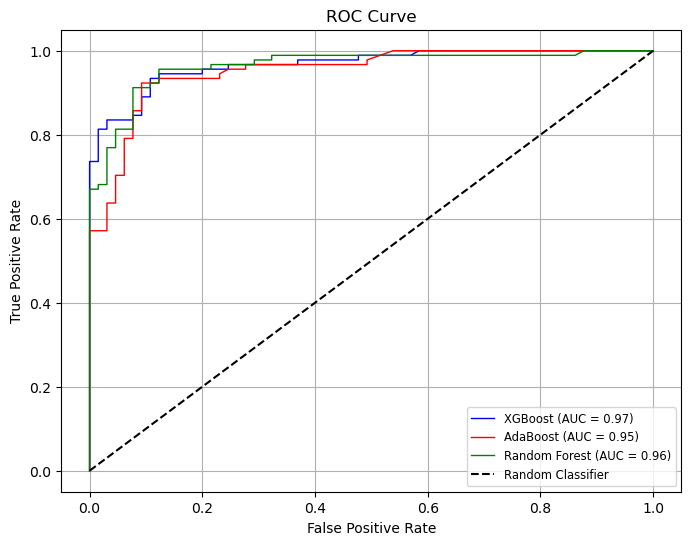

In [74]:
fpr_xgb, tpr_xgb, _ = roc_curve(y_test_prep, y_proba_xgb)
fpr_ada, tpr_ada, _ = roc_curve(y_test_prep, y_proba_ada)
fpr_rf, tpr_rf, _ = roc_curve(y_test_prep, y_proba_rf)

# Compute AUC scores
auc_xgb = auc(fpr_xgb, tpr_xgb)
auc_ada = auc(fpr_ada, tpr_ada)
auc_rf = auc(fpr_rf, tpr_rf)

# Plot the ROC curves
plt.figure(figsize=(8, 6))
plt.plot(fpr_xgb, tpr_xgb, 'b-', linewidth=1, label=f'XGBoost (AUC = {auc_xgb:.2f})')
plt.plot(fpr_ada, tpr_ada, 'r-', linewidth=1, label=f'AdaBoost (AUC = {auc_ada:.2f})')
plt.plot(fpr_rf, tpr_rf, 'g-', linewidth=1, label=f'Random Forest (AUC = {auc_rf:.2f})')

# Plot the random classifier line
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(fontsize='small')
plt.grid(True)
plt.show()

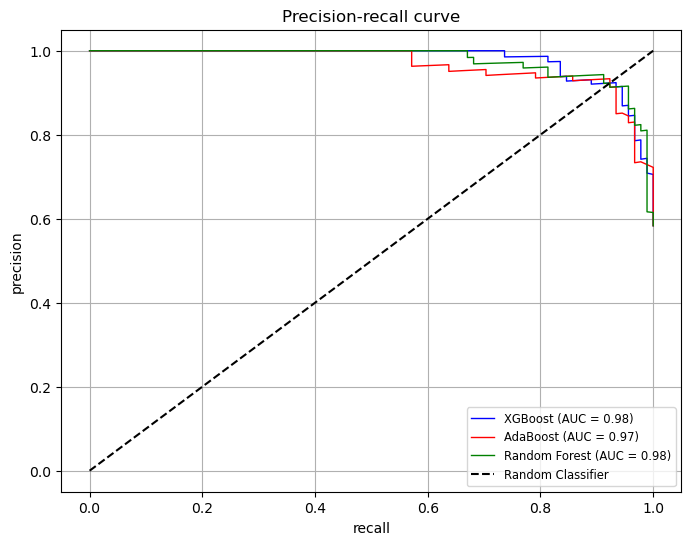

In [75]:
precision_xgb,recall_xgb,treshold = precision_recall_curve(y_test_prep,y_proba_xgb)
precision_ada,recall_ada,threshold = precision_recall_curve(y_test_prep,y_proba_ada)
precision_rf,recall_rf,threshold = precision_recall_curve(y_test_prep,y_proba_rf)

# Compute AUC scores
auc_xgb = auc(recall_xgb, precision_xgb)
auc_ada = auc(recall_ada, precision_ada)
auc_rf = auc(recall_rf, precision_rf)

# Plot precision-recall curves
plt.figure(figsize=(8, 6))
plt.plot(recall_xgb,precision_xgb,'b-',linewidth = 1,label=f'XGBoost (AUC = {auc_xgb:.2f})')
plt.plot(recall_ada,precision_ada,'r-',linewidth = 1, label = f'AdaBoost (AUC = {auc_ada:.2f})')
plt.plot(recall_rf,precision_rf,'g-',linewidth = 1, label = f'Random Forest (AUC = {auc_rf:.2f})')

# Plot the random classifier line
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')

plt.xlabel('recall')
plt.ylabel('precision')
plt.legend(fontsize = 'small')
plt.title('Precision-recall curve')
plt.grid()
plt.show()

We can see in both ROC curve and Precisio-recall curve, XGBoost give the highest Area Under Curve. Therefore XGBoost appear as the best performing model. Therefore we will select XGBoost Classifier as the final best performing model

### Check for feature importance

In [68]:
transformer_cat_cols = preprocess_transformer.named_transformers_['categorical'].get_feature_names_out(cat_cols)

In [69]:
new_cols1 = num_cols + list(transformer_cat_cols)

C:\Users\ASUS\AppData\Local\Temp\ipykernel_34568\1956719071.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importances_sorted.values, y=feature_importances_sorted.index, palette='viridis')


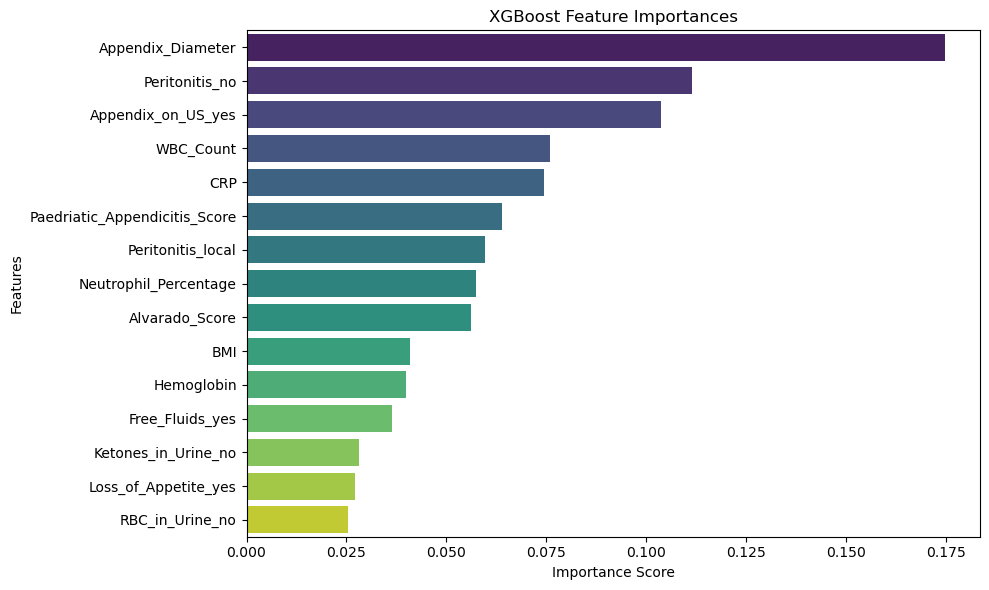

In [78]:
feature_importances = pd.Series(model_xgb_tuned.feature_importances_, index=new_cols1)
feature_importances_sorted = feature_importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importances_sorted.values, y=feature_importances_sorted.index, palette='viridis')
plt.title('XGBoost Feature Importances')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

In [79]:
feature_importances.sort_values()

Age                                     0.000000
Height                                  0.000000
Weight                                  0.000000
Body_Temperature                        0.000000
RDW                                     0.000000
Thrombocyte_Count                       0.000000
Sex_male                                0.000000
RBC_Count                               0.000000
Ketones_in_Urine_++                     0.000000
Ketones_in_Urine_+++                    0.000000
RBC_in_Urine_++                         0.000000
Neutrophilia_yes                        0.000000
Coughing_Pain_yes                       0.000000
Nausea_yes                              0.000000
Lower_Right_Abd_Pain_yes                0.000000
Migratory_Pain_yes                      0.000000
WBC_in_Urine_+++                        0.000000
WBC_in_Urine_++                         0.000000
RBC_in_Urine_+++                        0.000000
Stool_normal                            0.000000
Stool_diarrhea      

We will drop some of the features with less important and refit the model using remaining features

Less important features:

1. Age
2. Height
3. Weight
4. Body_Temperature
5. RDW
6. Thrombocyte_Count
7. Sex
8. RBC_Count
9. Neutrophilia
10. Coughing_Pain
11. WBC_in_Urine
12. Stool

In [80]:
less_important_features = ['Age','Height','Weight','Body_Temperature','RDW','Thrombocyte_Count','Sex','RBC_Count','Neutrophilia','Coughing_Pain','WBC_in_Urine','Stool']

In [81]:
X_train_imputed_selected = X_train_imputed.drop(columns=less_important_features)
X_test_imputed_selected = X_test_imputed.drop(columns=less_important_features)

In [82]:
cat_cols_selected = X_train_imputed_selected.select_dtypes(include='object').columns

In [83]:
num_cols_selected = [x for x in X_train_imputed_selected.columns if x not in cat_cols_selected]

In [84]:
preprocess_transformer1 = ColumnTransformer([
    ('numerical',StandardScaler(),num_cols_selected),
    ('categorical',OneHotEncoder(drop='first',sparse_output=False,handle_unknown='ignore'),cat_cols_selected)
])

In [85]:
preprocess_pipeline1 = Pipeline([
    ('preprocess',preprocess_transformer1)
])

In [86]:
preprocess_pipeline1.fit(X_train_imputed_selected)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('numerical', StandardScaler(),
                                                  []),
                                                 ('categorical',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False),
                                                  Index(['BMI', 'Hemoglobin', 'CRP', 'Alvarado_Score',
       'Paedriatic_Appendicitis_Score', 'Appendix_Diameter', 'WBC_Count',
       'Neutrophil_Percentage', 'Appendix_on_US', 'Migratory_Pain',
       'Lower_Right_Abd_Pain', 'Contralateral_Rebound_Tenderness', 'Nausea',
       'Loss_of_Appetite', 'Ketones_in_Urine', 'RBC_in_Urine', 'Dysuria',
       'Peritonitis', 'Psoas_Sign', 'Ipsilateral_Rebound_Tenderness',
       'Free_Fluids'],
      dtype='object'))]))])

In [87]:
X_train_imputed_selected_prep = preprocess_transformer1.transform(X_train_imputed_selected)
X_test_imputed_selected_prep = preprocess_transformer1.transform(X_test_imputed_selected)

C:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1, 2, 5, 6, 7] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [88]:
model_xgb_reduced = XGBClassifier(colsample_bytree=1,
                          gamma=0,
                          learning_rate=0.2,
                          max_depth=3,
                          n_estimators=300,
                          subsample=1) 
model_xgb_reduced.fit(X_train_imputed_selected_prep,y_train_prep)
model_xgb_reduced.score(X_test_imputed_selected_prep,y_test_prep)

0.8461538461538461

When we reduced the number of features in the dataset, the model performance droped

In [89]:
y_pred_xgb_reduced = model_xgb_reduced.predict(X_test_imputed_selected_prep)

In [90]:
print(classification_report(y_test_prep,y_pred_xgb_reduced))

              precision    recall  f1-score   support

           0       0.84      0.78      0.81        65
           1       0.85      0.89      0.87        91

    accuracy                           0.85       156
   macro avg       0.84      0.84      0.84       156
weighted avg       0.85      0.85      0.85       156



### Perform Hyperparameter tuning after reduction

In [123]:
param_grid_xgb1 = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'gamma': [0, 1, 5]
}

In [124]:
grid = GridSearchCV(XGBClassifier(),param_grid=param_grid_xgb1,cv=3,n_jobs=-1)
grid.fit(X_train_imputed_selected_prep,y_train_prep)

GridSearchCV(cv=3,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, feature_weights=None,
                                     gamma=None, grow_policy=None,
                                     importance_type=None,
                                     interaction_constraints=Non...
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'colsample_bytree': [0.6, 0.8, 1.0],
                         'gamma': [0, 1, 5], 'learning_rate': [0.01, 0.1, 0.2],
                         'max_depth': [3, 5, 7],
                         'n_estimators': [100, 200, 300],
                         'subsample': [0.6, 0.8, 1.0]})

In [125]:
grid.best_score_

np.float64(0.8461538461538461)

In [126]:
grid.best_params_

{'colsample_bytree': 0.6,
 'gamma': 0,
 'learning_rate': 0.01,
 'max_depth': 5,
 'n_estimators': 300,
 'subsample': 0.6}

In [127]:
model_xgb_tuned_reduced = XGBClassifier(colsample_bytree=0.6,
                          gamma=0,
                          learning_rate=0.01,
                          max_depth=5,
                          n_estimators=300,
                          subsample=0.6)
model_xgb_tuned_reduced.fit(X_train_imputed_selected_prep,y_train_prep)
model_xgb_tuned_reduced.score(X_test_imputed_selected_prep,y_test_prep)

0.8461538461538461

In [128]:
y_pred_xgb_tuned_reduced = model_xgb_tuned_reduced.predict(X_test_imputed_selected_prep)

In [129]:
print(classification_report(y_test_prep,y_pred_xgb_tuned_reduced))

              precision    recall  f1-score   support

           0       0.87      0.74      0.80        65
           1       0.83      0.92      0.88        91

    accuracy                           0.85       156
   macro avg       0.85      0.83      0.84       156
weighted avg       0.85      0.85      0.84       156



In [120]:
X_train_imputed_prep = pd.DataFrame(X_train_imputed_prep,columns=new_cols1)
X_test_imputed_prep = pd.DataFrame(X_test_imputed_prep,columns=new_cols1)

## use SHAP to interpret the model

In [121]:
import shap
shap.initjs()

In [122]:
explainer = shap.TreeExplainer(model_xgb_tuned)
shap_values = explainer.shap_values(X_test_imputed_prep)

In [131]:
X_test_original = scaler.inverse_transform(X_test_scaled)

NameError: name 'scaler' is not defined

#### Summary plot (feature importance + distribution of impact)

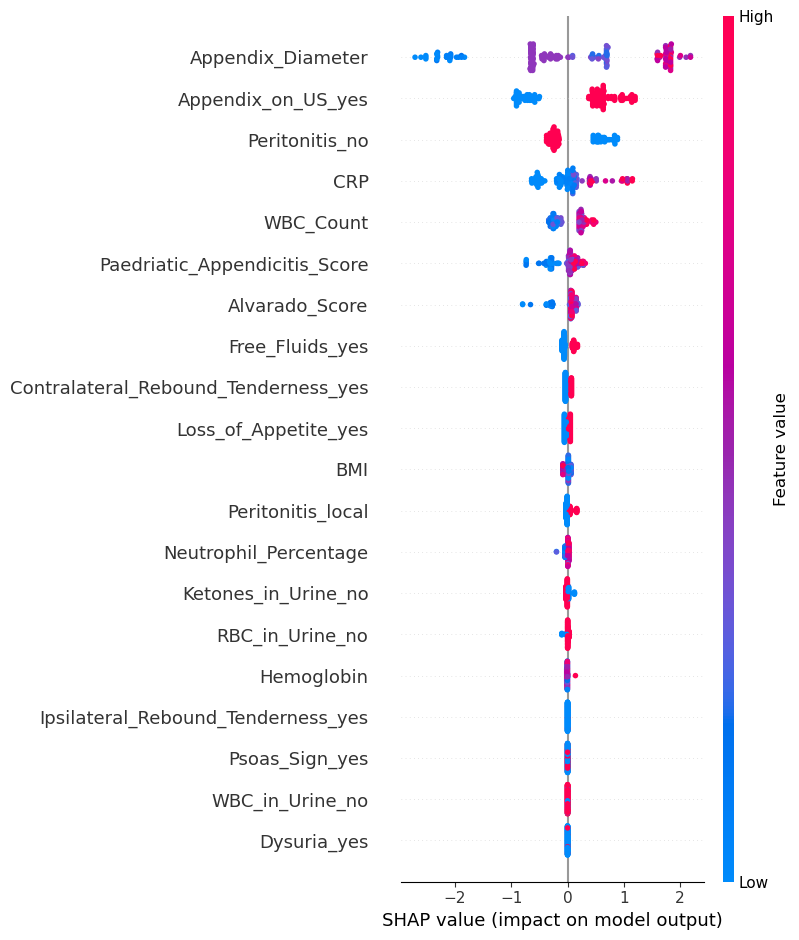

In [123]:
shap.summary_plot(shap_values, X_test_imputed_prep)

#### Feature importance bar chart

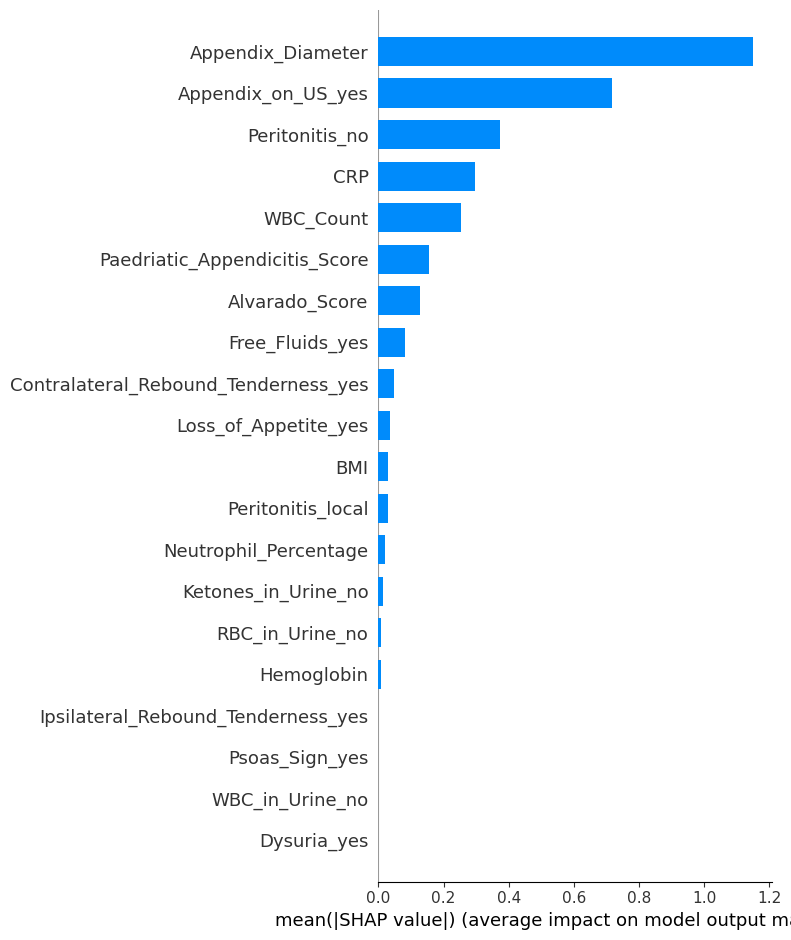

In [124]:
shap.summary_plot(shap_values, X_test_imputed_prep, plot_type="bar")

#### Force plot (individual prediction explanation)

In [102]:
shap.force_plot(explainer.expected_value, shap_values, X_test_imputed_prep)

#### Dependence plot (effect of one feature across dataset)

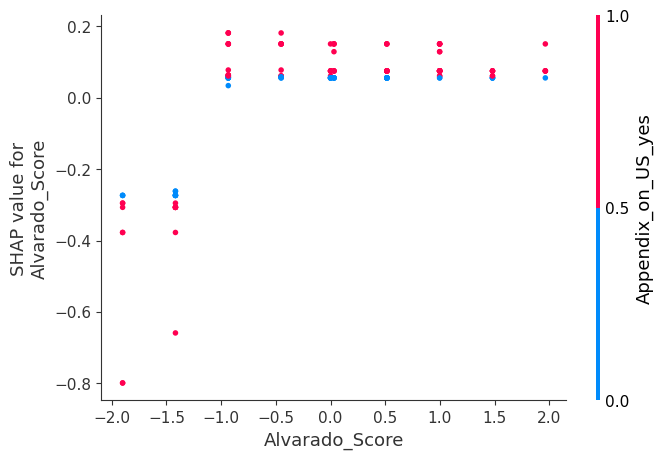

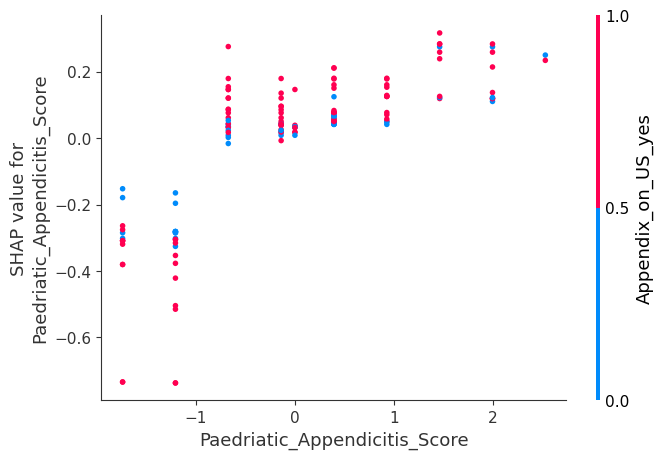

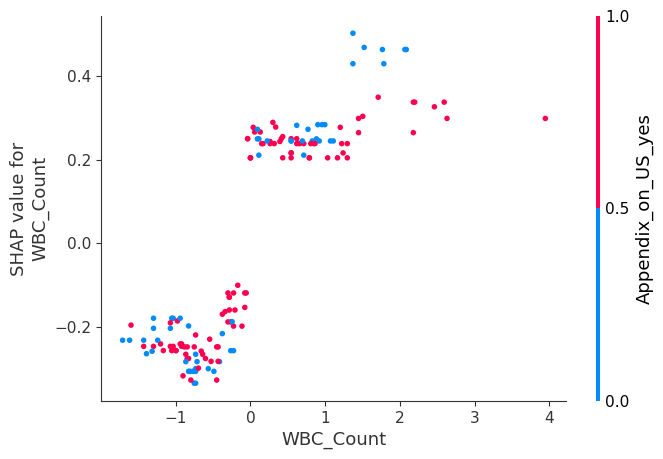

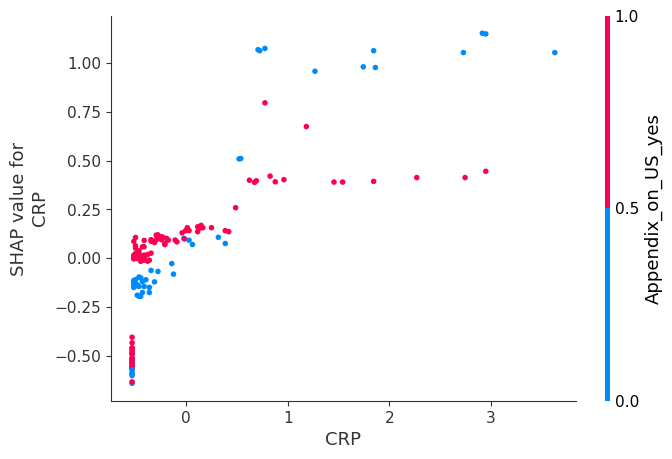

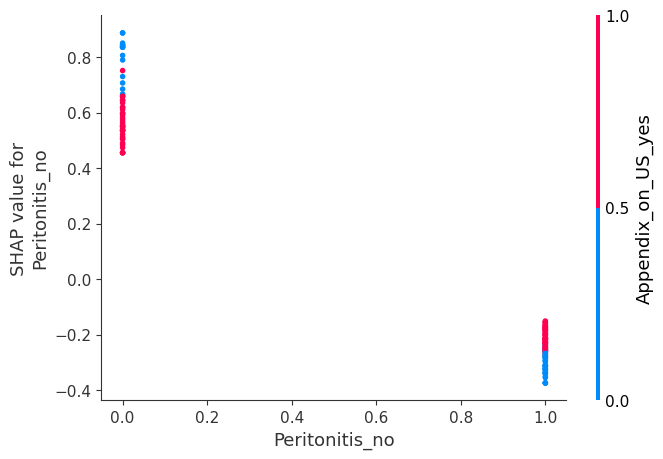

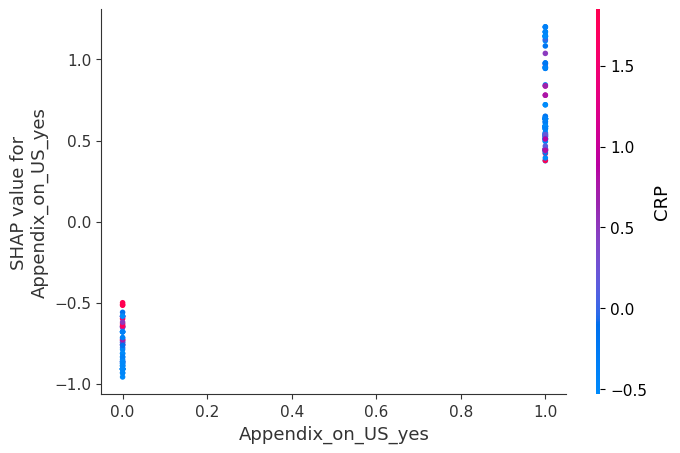

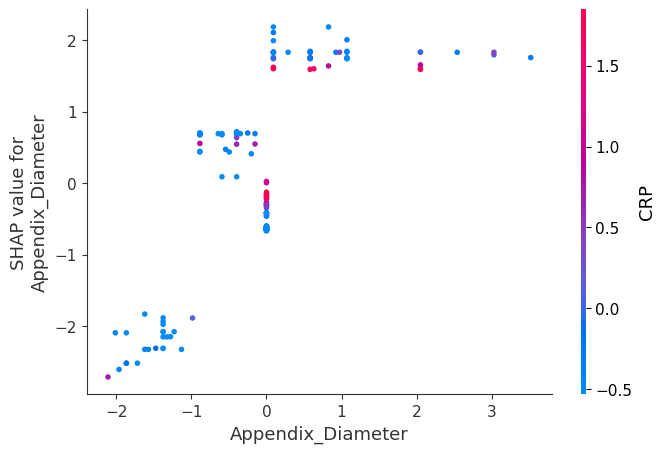

In [126]:
feature_importance = np.abs(shap_values).mean(axis=0)
top_features = np.argsort(feature_importance)[-7:]

for feat in top_features:
    shap.dependence_plot(feat, shap_values, X_test_imputed_prep)

In [143]:
scaler = preprocess_transformer.named_transformers_['numerical']
X_num_original = pd.DataFrame(
    # Use named_steps instead of transformers_ to access pipeline components
    scaler.inverse_transform(preprocess_pipeline.named_steps['preprocess'].named_transformers_['numerical'].transform(X_test_imputed[num_cols])),
    columns=num_cols
)

X_cat = X_test_imputed_prep[transformer_cat_cols].copy()

X_test_original = pd.concat([X_num_original, X_cat], axis=1)

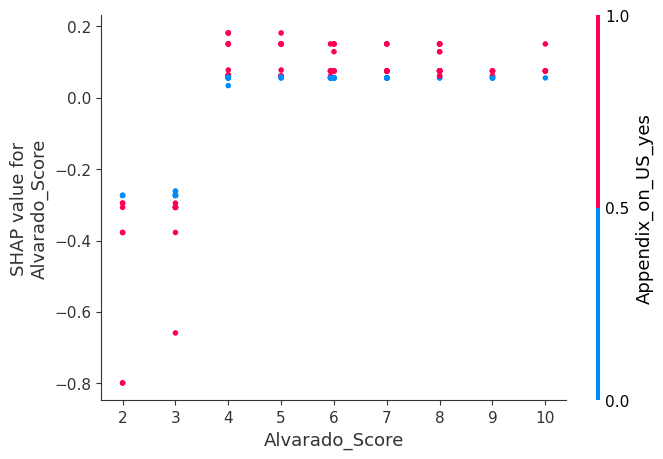

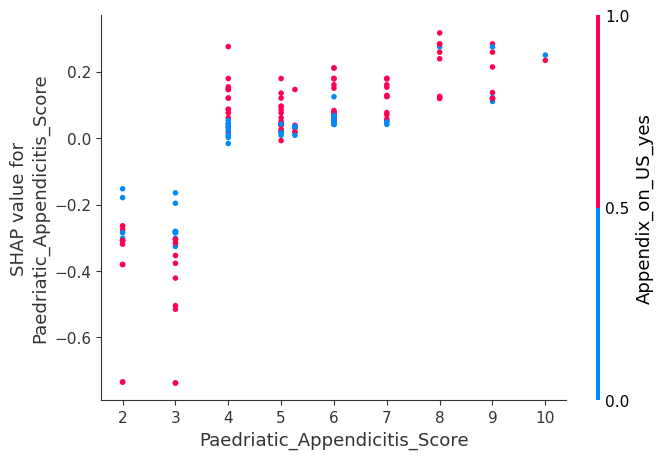

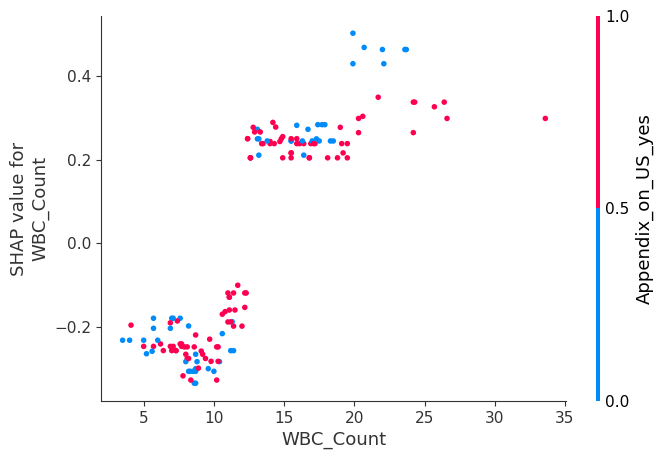

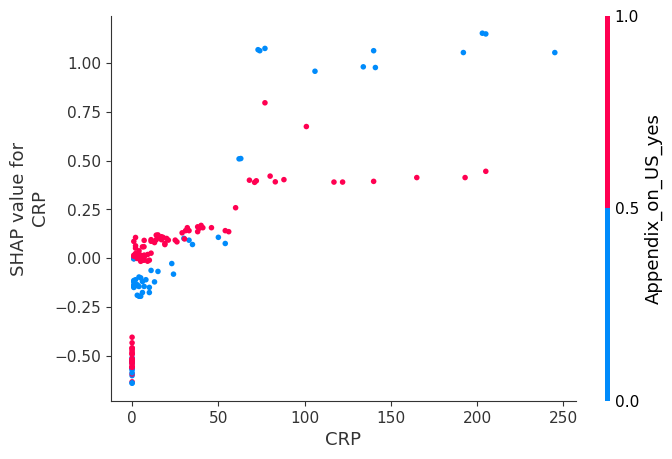

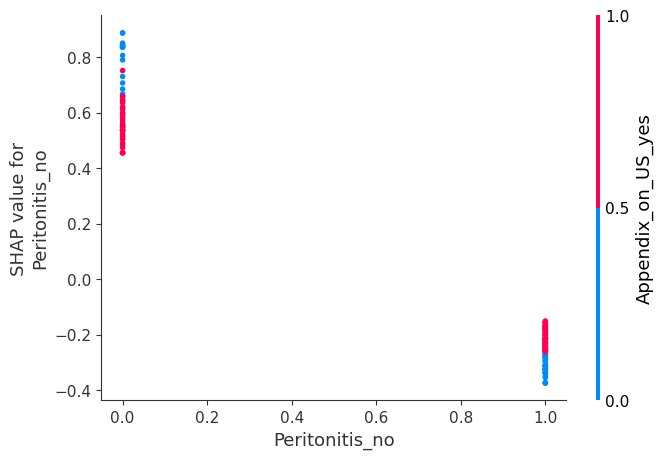

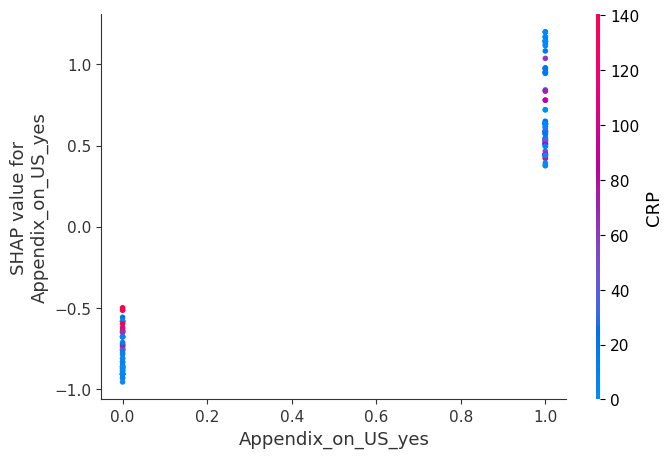

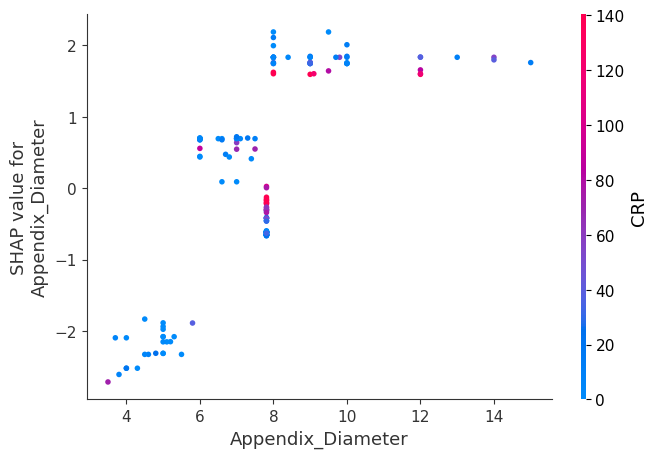

In [145]:
feature_importance = np.abs(shap_values).mean(axis=0)
top_features = np.argsort(feature_importance)[-7:]

for feat in top_features:
    shap.dependence_plot(feat, shap_values, X_test_original)

### Export the model

In [92]:
scaler = StandardScaler()
scaler.fit(X_train[num_cols])

StandardScaler()

In [93]:
import joblib

In [94]:
joblib.dump(scaler,'scaler.pickle')

['scaler.pickle']

In [97]:
import json

In [72]:
X_train_imputed_prep = pd.DataFrame(X_train_imputed_prep,columns=new_cols1)

In [74]:
columns = {
    'data_columns':[col for col in X_train_imputed_prep.columns]
}

In [75]:
with open('data_columns.json','w') as f:
    json.dump(columns,f)

In [113]:
columns_to_scale = {
    'columns_to_scale':['Age', 'BMI', 'Height', 'Weight', 'Alvarado_Score', 
                    'Paedriatic_Appendicitis_Score', 'Appendix_Diameter', 
                    'Body_Temperature', 'WBC_Count', 'Neutrophil_Percentage', 
                    'RBC_Count', 'Hemoglobin', 'RDW', 'Thrombocyte_Count', 'CRP']
}

In [114]:
with open('columns_to_scale.json','w') as f:
    json.dump(columns_to_scale,f)

In [103]:
import pickle

In [104]:
with open('model.pickle','wb') as f:
    pickle.dump(model_xgb_tuned,f)

In [107]:
def estimate_appendicities(Age,BMI,Sex,Height,Weight,Alvarado_Score,Paedriatic_Appendicitis_Score,Appendix_on_US,Appendix_Diameter,Migratory_Pain,Lower_Right_Abd_Pain,Contralateral_Rebound_Tenderness,Coughing_Pain,Nausea,Loss_of_Appetite,Body_Temperature,WBC_Count,Neutrophil_Percentage,Neutrophilia,RBC_Count,Hemoglobin,RDW,Thrombocyte_Count,Ketones_in_Urine,RBC_in_Urine,WBC_in_Urine,CRP,Dysuria,Stool,Peritonitis,Psoas_Sign,Ipsilateral_Rebound_Tenderness,Free_Fluids):

    X = np.zeros(len(X_train.columns))
    fields = {
        'Appendix_on_US': Appendix_on_US,
        'Migratory_Pain': Migratory_Pain,
        'Lower_Right_Abd_Pain': Lower_Right_Abd_Pain,
        'Contralateral_Rebound_Tenderness': Contralateral_Rebound_Tenderness,
        'Coughing_Pain': Coughing_Pain,
        'Nausea': Nausea,
        'Loss_of_Appetite': Loss_of_Appetite,
        'Neutrophilia':Neutrophilia,
        'Ketones_in_Urine':Ketones_in_Urine,
        'RBC_in_Urine':RBC_in_Urine,
        'WBC_in_Urine':WBC_in_Urine,
        'Dysuria':Dysuria,
        'Stool':Stool,
        'Peritonitis':Peritonitis,
        'Psoas_Sign':Psoas_Sign,
        'Ipsilateral_Rebound_Tenderness':Ipsilateral_Rebound_Tenderness,
        'Free_Fluids':Free_Fluids
    }

    for feature,value in fields.items():
        column_name = f"{feature}_{value}"
        if column_name in X_train_imputed_prep.columns:
            index = X_train_imputed_prep.columns.get_loc(column_name)
            X[index] = 1

    numerical_input = np.array([[Age,BMI,Height,Weight,Alvarado_Score,Paedriatic_Appendicitis_Score,Appendix_Diameter,Body_Temperature,WBC_Count,Neutrophil_Percentage,RBC_Count,Hemoglobin,RDW,Thrombocyte_Count,CRP]])
    scaled_values = scaler.transform(numerical_input)[0]

    columns_to_scale = ['Age', 'BMI', 'Height', 'Weight', 'Alvarado_Score', 
                    'Paedriatic_Appendicitis_Score', 'Appendix_Diameter', 
                    'Body_Temperature', 'WBC_Count', 'Neutrophil_Percentage', 
                    'RBC_Count', 'Hemoglobin', 'RDW', 'Thrombocyte_Count', 'CRP']

    for i,column in enumerate(columns_to_scale):
        col_index = X_train_imputed_prep.columns.get_loc(column)
        X[col_index] = scaled_values[i]
        
    prediction = model.predict([X])[0]
    result = ''
    if prediction == 1:
        result = 'Yes'
    else:
        result = 'No'

    probability = model.predict_proba([X])[0][1]
    return result,probability

In [115]:
X_train.columns

Index(['Age', 'BMI', 'Sex', 'Height', 'Weight', 'Alvarado_Score',
       'Paedriatic_Appendicitis_Score', 'Appendix_on_US', 'Appendix_Diameter',
       'Migratory_Pain', 'Lower_Right_Abd_Pain',
       'Contralateral_Rebound_Tenderness', 'Coughing_Pain', 'Nausea',
       'Loss_of_Appetite', 'Body_Temperature', 'WBC_Count',
       'Neutrophil_Percentage', 'Neutrophilia', 'RBC_Count', 'Hemoglobin',
       'RDW', 'Thrombocyte_Count', 'Ketones_in_Urine', 'RBC_in_Urine',
       'WBC_in_Urine', 'CRP', 'Dysuria', 'Stool', 'Peritonitis', 'Psoas_Sign',
       'Ipsilateral_Rebound_Tenderness', 'Free_Fluids'],
      dtype='object')

Demographic
1. Age
2. BMI
3. Sex
4. Height
5. Weight

Scoring
1. Alvarado_Score
2. Paedriatic_Appendicitis_Score

Clinical
1. Migratory_Pain
2. Lower_Right_Abd_Pain
3. Contralateral_Rebound_Tenderness
4. Coughing_Pain
5. Nausea
6. Loss_of_Appetite
7. Body_Temperature
8. Dysuria
9. Stool
10. Peritonitis
11. Psoas_Sign
12. Ipsilateral_Rebound_Tenderness

Laboratory
1. WBC_Count
2. Neutrophil_Percentage
3. Neutrophilia
4. RBC_Count
5. Hemoglobin
6. RDW
7. Thrombocyte_Count
8. Ketones_in_Urine
9. RBC_in_Urine
10. WBC_in_Urine
11. CRP


US
1. Appendix_on_US
2. Appendix_Diameter
3. Free_Fluids

In [33]:
for i in cat_cols:
    print(i,' : ',X_train_imputed[i].unique())

Sex  :  ['male' 'female']
Appendix_on_US  :  ['yes' 'no']
Migratory_Pain  :  ['no' 'yes']
Lower_Right_Abd_Pain  :  ['yes' 'no']
Contralateral_Rebound_Tenderness  :  ['yes' 'no']
Coughing_Pain  :  ['yes' 'no']
Nausea  :  ['yes' 'no']
Loss_of_Appetite  :  ['no' 'yes']
Neutrophilia  :  ['yes' 'no']
Ketones_in_Urine  :  ['no' '++' '+++' '+']
RBC_in_Urine  :  ['no' '+' '++' '+++']
WBC_in_Urine  :  ['no' '+' '++' '+++']
Dysuria  :  ['no' 'yes']
Stool  :  ['normal' 'constipation' 'diarrhea' 'constipation, diarrhea']
Peritonitis  :  ['local' 'no' 'generalized']
Psoas_Sign  :  ['no' 'yes']
Ipsilateral_Rebound_Tenderness  :  ['no' 'yes']
Free_Fluids  :  ['no' 'yes']


In [43]:
X_train['Weight'].min()

3.96

In [58]:
X_train['Peritonitis'].describe()

count     619
unique      3
top        no
freq      437
Name: Peritonitis, dtype: object

In [40]:
import matplotlib.pyplot as plt

In [86]:
X_train[:3]

,Age,BMI,Sex,Height,Weight,Alvarado_Score,Paedriatic_Appendicitis_Score,Appendix_on_US,Appendix_Diameter,Migratory_Pain,...,Ketones_in_Urine,RBC_in_Urine,WBC_in_Urine,CRP,Dysuria,Stool,Peritonitis,Psoas_Sign,Ipsilateral_Rebound_Tenderness,Free_Fluids
697,8.999316,17.677819,male,147.0,38.2,8.0,8.0,yes,10.0,no,...,NaN,NaN,NaN,20.0,no,normal,local,no,NaN,no
640,5.111567,14.239943,female,106.0,16.0,8.0,7.0,yes,8.6,yes,...,no,no,no,2.0,NaN,NaN,local,NaN,NaN,yes
133,10.930000,18.400000,male,137.5,35.0,3.0,3.0,yes,6.0,yes,...,no,no,no,0.0,no,normal,no,no,no,yes


In [90]:
X_train.loc[133]

Age                                  10.93
BMI                                   18.4
Sex                                   male
Height                               137.5
Weight                                35.0
Alvarado_Score                         3.0
Paedriatic_Appendicitis_Score          3.0
Appendix_on_US                         yes
Appendix_Diameter                      6.0
Migratory_Pain                         yes
Lower_Right_Abd_Pain                   yes
Contralateral_Rebound_Tenderness        no
Coughing_Pain                           no
Nausea                                  no
Loss_of_Appetite                        no
Body_Temperature                      36.5
WBC_Count                              6.8
Neutrophil_Percentage                 51.0
Neutrophilia                            no
RBC_Count                             5.13
Hemoglobin                            14.0
RDW                                   13.3
Thrombocyte_Count                    338.0
Ketones_in_

In [88]:
y_train[:3]

697       appendicitis
640       appendicitis
133    no appendicitis
Name: Diagnosis, dtype: object